In [1]:
import numpy as np
from sklearn.linear_model import Perceptron

# AND Gate
X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y_and = np.array([0,0,0,1])

model = Perceptron(max_iter=1000)

model.fit(X,y_and)

print("AND Predictions:")
print(model.predict(X))

AND Predictions:
[0 0 0 1]


In [2]:
y_or = np.array([0,1,1,1])

model = Perceptron(max_iter=1000)

model.fit(X,y_or)

print("OR Predictions:")
print(model.predict(X))

OR Predictions:
[0 1 1 1]


In [3]:
import numpy as np
from sklearn.neural_network import MLPClassifier

X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y = np.array([0,1,1,0])

mlp = MLPClassifier(
    hidden_layer_sizes=(4,),
    activation='tanh',
    solver='lbfgs',
    max_iter=10000,
    random_state=42
)

mlp.fit(X,y)

print("XOR Predictions:")
print(mlp.predict(X))

XOR Predictions:
[0 1 1 0]


In [4]:
from sklearn.datasets import load_digits

digits = load_digits()

X = digits.data
y = digits.target

print(X.shape)
print(y.shape)

(1797, 64)
(1797,)


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (1149, 64)
Validation: (288, 64)
Test: (360, 64)


In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_val = scaler.transform(X_val)

X_test = scaler.transform(X_test)

In [7]:
from sklearn.neural_network import MLPClassifier

dnn = MLPClassifier(
    hidden_layer_sizes=(128,64,32),
    activation='relu',
    solver='adam',
    max_iter=100,
    random_state=42
)

dnn.fit(X_train,y_train)

MLPClassifier(hidden_layer_sizes=(128, 64, 32), max_iter=100, random_state=42)

In [8]:
from sklearn.metrics import accuracy_score

train_pred = dnn.predict(X_train)
val_pred = dnn.predict(X_val)
test_pred = dnn.predict(X_test)

print("Train Accuracy:",
      accuracy_score(y_train,train_pred))

print("Validation Accuracy:",
      accuracy_score(y_val,val_pred))

print("Test Accuracy:",
      accuracy_score(y_test,test_pred))

Train Accuracy: 1.0
Validation Accuracy: 0.9791666666666666
Test Accuracy: 0.975


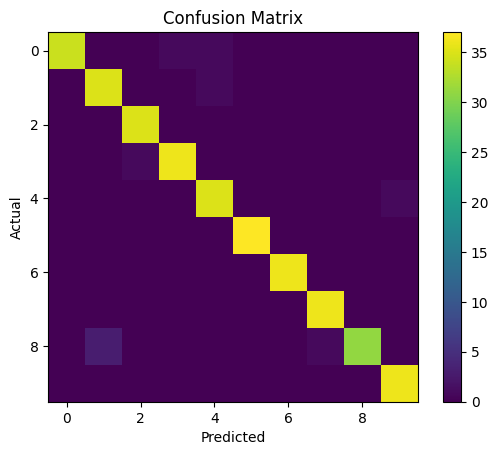

In [9]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test,test_pred)

plt.imshow(cm)
plt.colorbar()
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

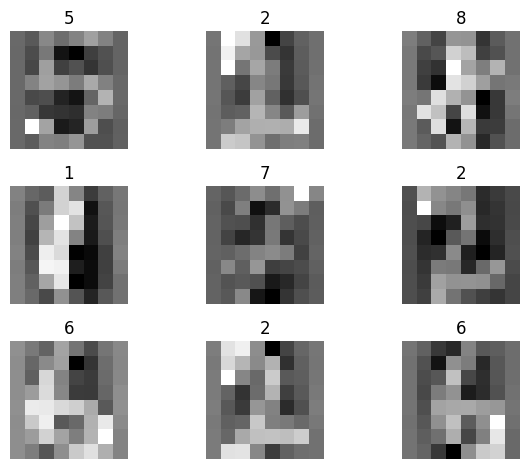

In [10]:
import matplotlib.pyplot as plt

for i in range(9):
    plt.subplot(3,3,i+1)

    img = X_test[i].reshape(8,8)

    plt.imshow(img,cmap='gray')

    plt.title(test_pred[i])

    plt.axis('off')

plt.tight_layout()
plt.show()